# Data Exploratory

- Peak GCVI
- District yield
- Location: India, Season: Kharif

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap
import rasterio as rio
import numpy as np
import geopandas as gpd
import seaborn as sns
import geopandas as gpd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/edliao/miniconda/envs/research/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [20]:
ee.Authenticate()
ee.Initialize(project='earth-intelligence-492621')

## GCVI

In [22]:
ee.Initialize(project='earth-intelligence-492621')

years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

peak_gcvi_years = [ee.Image(f'projects/earth-intelligence-492621/assets/peak_gcvi_kharif_{year}_punjab') for year in years]

for peak_gcvi, year in zip(peak_gcvi_years, years):
    filename = f'data/assets/peak_gcvi_kharif_{year}_punjab.tif'
    geemap.ee_export_image(
        peak_gcvi,
        filename=filename,
        scale=500,
        crs='EPSG:4326',
        region=peak_gcvi.geometry(),
    )

Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/assets/peak_gcvi_kharif_2017_punjab.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/assets/peak_gcvi_kharif_2018_punjab.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/assets/peak_gcvi_kharif_2019_punjab.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/assets/peak_gcvi_kharif_2020_punjab.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/assets/peak_gcvi_kharif_2021_punjab.tif
Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/data/assets/peak_gcvi_kharif_2022_punjab.tif
Generating URL ...
Please wait ...
Data downloaded to /Use

Min: 0.5797356963157654
Max: nan
Dimensions: (662, 686)


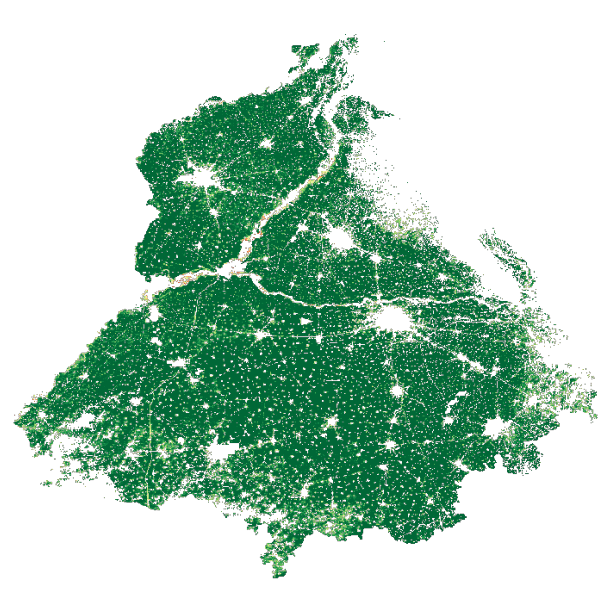

In [5]:
with rio.open('../../data/gcvi/peak_gcvi_kharif_2023_punjab_crop.tif') as src:
    peak_gcvi = src.read(1).astype('float32')
    # Handle no-data values
    peak_gcvi[peak_gcvi == src.nodata] = np.nan
    # Print basic statistics
    print(f"Min: {peak_gcvi[peak_gcvi>-2].min()}")
    print(f"Max: {peak_gcvi.max()}")
    print(f"Dimensions: {peak_gcvi.shape}")

plt.figure(figsize=(10, 6))
img = plt.imshow(peak_gcvi, cmap='RdYlGn', vmin=0, vmax=5)
# plt.colorbar(img, label='GCVI')
# plt.title('Peak GCVI – Kharif 2023, Punjab')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# How many pixels fall within different GCVI ranges?
unique, counts = np.unique(np.floor(peak_gcvi), return_counts=True)
for u, c in zip(unique, counts):
    print(f"GCVI {u}: {c} pixels")

GCVI -inf: 249949 pixels
GCVI -1.0: 6 pixels
GCVI 0.0: 1362 pixels
GCVI 1.0: 5644 pixels
GCVI 2.0: 14207 pixels
GCVI 3.0: 23929 pixels
GCVI 4.0: 37217 pixels
GCVI 5.0: 45093 pixels
GCVI 6.0: 35535 pixels
GCVI 7.0: 22658 pixels
GCVI 8.0: 12145 pixels
GCVI 9.0: 5507 pixels
GCVI 10.0: 2195 pixels
GCVI 11.0: 835 pixels
GCVI 12.0: 293 pixels
GCVI 13.0: 118 pixels
GCVI 14.0: 57 pixels
GCVI 15.0: 33 pixels
GCVI 16.0: 6 pixels
GCVI 17.0: 8 pixels
GCVI 18.0: 8 pixels
GCVI 19.0: 6 pixels
GCVI 20.0: 5 pixels
GCVI 21.0: 4 pixels
GCVI 22.0: 1 pixels
GCVI 23.0: 2 pixels
GCVI 24.0: 1 pixels
GCVI 25.0: 1 pixels
GCVI 26.0: 1 pixels
GCVI 31.0: 1 pixels
GCVI 42.0: 1 pixels
GCVI 52.0: 1 pixels
GCVI 72.0: 1 pixels
GCVI 155.0: 1 pixels
GCVI 514.0: 1 pixels


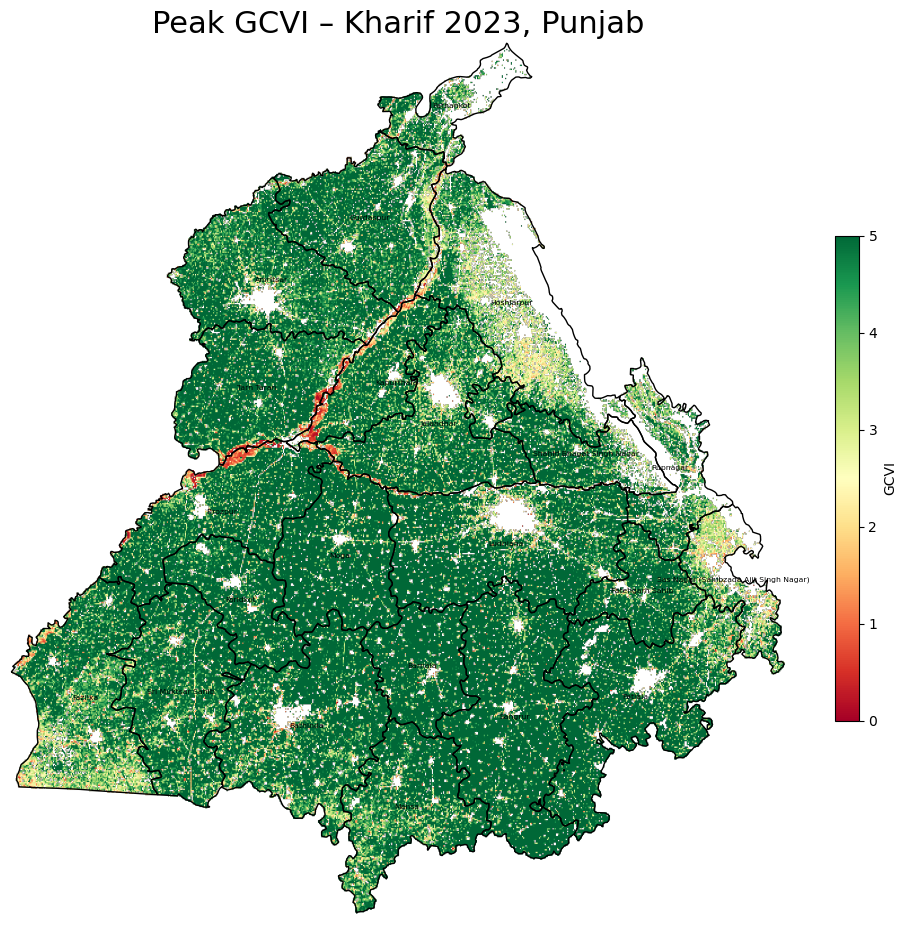

In [ ]:
from rasterio.plot import show
import matplotlib.colors as mcolors

districts = gpd.read_file('data/Punjab_Districts_GAUL/Punjab_Districts_GAUL.shp')
districts = districts.to_crs('EPSG:4326')
fig, ax = plt.subplots(figsize=(10, 10))

with rio.open('data/assets/peak_gcvi_kharif_2023_punjab.tif') as src:
    show(src, ax=ax, cmap='RdYlGn', vmin=0, vmax=5)
    districts = districts.to_crs(src.crs)

districts.plot(ax=ax, color='none', edgecolor='black', linewidth=1)
ax.set_title('Peak GCVI – Kharif 2023, Punjab', fontsize=22)

# District name labels
for _, row in districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['gaul2_name'], xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=5.5, color='black')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=mcolors.Normalize(vmin=0, vmax=5))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='GCVI', shrink=0.5)

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import rasterio
import numpy as np
from rasterio.plot import show
from rasterstats import zonal_stats

# Step 1: Clean the raster — replace -inf with NaN
input_tif  = 'data/assets/peak_gcvi_kharif_2023_punjab.tif'
cleaned_tif = 'data/assets/peak_gcvi_cleaned_punjab.tif'

with rasterio.open(input_tif) as src:
    data = src.read(1).astype(float)
    profile = src.profile
    
    # Replace -inf, inf, and unrealistic values with NaN
    data[np.isinf(data)] = np.nan
    # data[data < 0]       = np.nan  # GCVI shouldn't be negative for crops
    
    profile.update(dtype=rasterio.float32, nodata=np.nan)
    
    with rasterio.open(cleaned_tif, 'w', **profile) as dst:
        dst.write(data.astype(np.float32), 1)

# Step 2: Run zonal stats on cleaned raster
stats = zonal_stats(
    districts,
    cleaned_tif,
    stats=['mean', 'min', 'max', 'median'],
    nodata=np.nan
)

districts['gcvi_mean']   = [s['mean']   for s in stats]
districts['gcvi_median'] = [s['median'] for s in stats]
districts['gcvi_min']    = [s['min']    for s in stats]
districts['gcvi_max']    = [s['max']    for s in stats]

print(districts[['gaul2_name', 'gcvi_mean', 'gcvi_median']].head(10))

        gaul2_name  gcvi_mean  gcvi_median
0         Amritsar   4.971748     4.996850
1          Barnala   6.690948     6.807962
2         Bathinda   5.533784     5.552200
3         Faridkot   5.934633     5.916201
4  Fatehgarh Sahib   5.685569     5.724463
5          Fazilka   4.514372     4.448278
6         Firozpur   5.443400     5.683544
7        Gurdaspur   5.025170     5.117744
8       Hoshiarpur   3.863943     3.698075
9        Jalandhar   5.075903     5.181063


Text(0.5, 1.0, 'Average GCVI per District – Kharif 2023, Punjab')

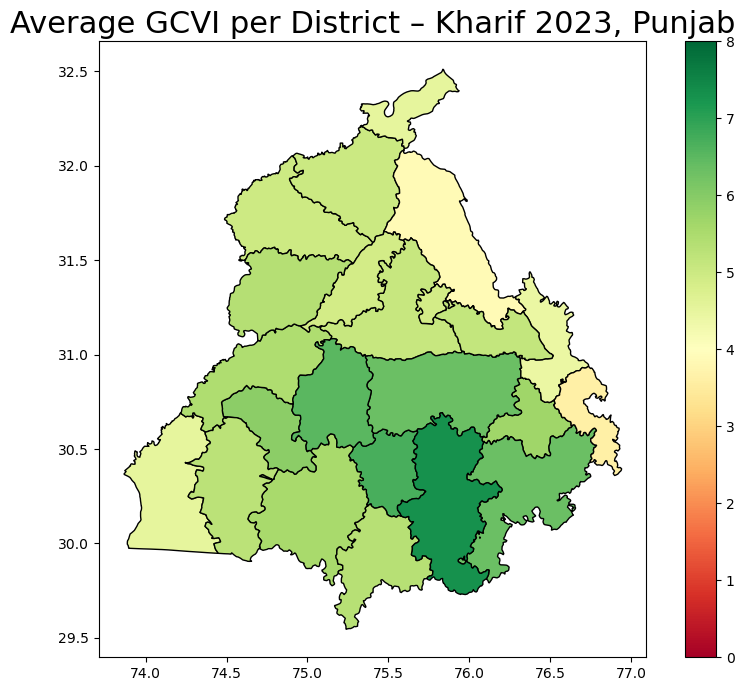

In [ ]:
# Visualize the gcvi mean per district using the shapefile and the computed zonal stats
fig, ax = plt.subplots(figsize=(10,8))
districts.plot(column='gcvi_mean', ax=ax, cmap='RdYlGn', legend=True, edgecolor='black', linewidth=1, vmin=0, vmax=8)

ax.set_title('Average GCVI per District – Kharif 2023, Punjab', fontsize=22)    

## District Yield Estimates

Source: https://upag.gov.in/dash-reports/desdistrictwisecompletedatasetreport

Units
- Area in Ha
- Production in Tonnes
- Yield kg/Ha

In [ ]:
# Explore the district yield data in India for 2023
df = pd.read_csv('data/DES-District-Data-For-2023-24.csv')
df.head()

filtered_data = df[(df['State'] == 'Punjab') & (df['Season'] == 'Kharif') & (df['Crop'] == 'Rice')]
filtered_data.head()

,State,District,Crop,Season,Area-2023-24,Production-2023-24,Yield-2023-24
16508,Punjab,Amritsar,Rice,Kharif,181000.0,578595.49,3197.0
16529,Punjab,Barnala,Rice,Kharif,114500.0,609991.16,5327.0
16550,Punjab,Bathinda,Rice,Kharif,199900.0,948624.56,4745.0
16578,Punjab,Faridkot,Rice,Kharif,117000.0,540248.57,4618.0
16599,Punjab,Fatehgarh Sahib,Rice,Kharif,87400.0,418164.55,4784.0


In [ ]:
# Generate summary stats for yield
filtered_data['Yield-2023-24'].describe()

count      23.000000
mean     4473.260870
std       602.616735
min      3197.000000
25%      4052.500000
50%      4553.000000
75%      4764.500000
max      5642.000000
Name: Yield-2023-24, dtype: float64

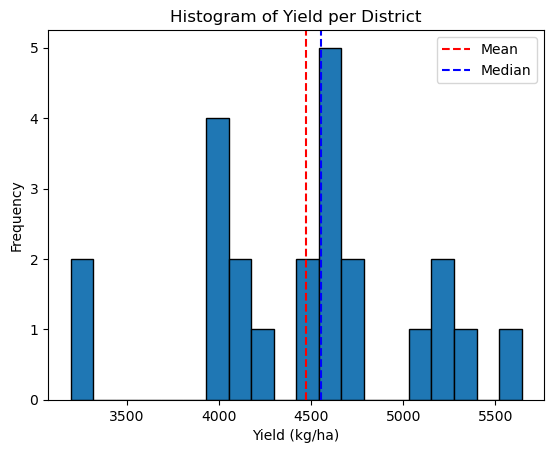

In [ ]:
# Generate a histogrram of yield value per district from filtered_data with the mean and median visualized on the figures
plt.hist(filtered_data['Yield-2023-24'], bins=20, edgecolor='black')
plt.axvline(filtered_data['Yield-2023-24'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(filtered_data['Yield-2023-24'].median(), color='blue', linestyle='--', label='Median')
plt.legend()
plt.title('Histogram of Yield per District')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Count the crop occurrences in Madhya Pradesh
filtered_data = df[(df['State'] == 'Punjab') & (df['Season'] == 'Kharif') ]
filtered_data['Crop'].value_counts()

Crop
Rice                         23
Cereals                      23
Total Food Grains            23
Maize                        18
Nutri/Coarse Cereals         18
Moong                        11
Tur                           7
Urad                          4
Bajra                         3
Shree Anna /Nutri Cereals     3
Name: count, dtype: int64

Applied filters to get a subset of the district-level yield data:
    - state: Madhya Pradesh
    - season: kharif
    - exclude aggregate crop rows, e.g., cereal, total food grains, nutri/coarse cereals, pulses, oilseeds, and total oilseeds

Output: Weighted average yield (kg/ha)

In [ ]:
df = pd.read_csv('data/DES-District-Data-For-2023-24.csv')

# Filter to Kharif only, exclude aggregate crop rows
AGGREGATE_CROPS = {
    'Cereals',
    'Nutri/Coarse Cereals',
    'Shree Anna /Nutri Cereals', 
    'Total Pulses',
    'Total Food Grains',
}

kharif = df[
    (df['State'] == 'Punjab') &
    (df['Season'] == 'Kharif') &
    (~df['Crop'].isin(AGGREGATE_CROPS))
].copy()

kharif['Area-2023-24']       = pd.to_numeric(kharif['Area-2023-24'], errors='coerce')
kharif['Production-2023-24'] = pd.to_numeric(kharif['Production-2023-24'], errors='coerce')

# Weighted average yield = total production / total area per district
district_yield = kharif.groupby(['State', 'District']).apply(
    lambda x: pd.Series({
        'total_area':       x['Area-2023-24'].sum(),
        'total_production': x['Production-2023-24'].sum(),
        'weighted_yield':   x['Production-2023-24'].sum() / x['Area-2023-24'].sum()
    })
).reset_index()

district_yield['weighted_yield'] = district_yield['weighted_yield'] * 1000  # Convert yield to kg/ha

# Rice area per district
rice_area = (
    kharif[kharif['Crop'] == 'Rice']
    .groupby('District')['Area-2023-24']
    .sum()
    .rename('rice_area_ha')
    .reset_index()
)

# Maize area per district
maize_area = (
    kharif[kharif['Crop'] == 'Maize']
    .groupby('District')['Area-2023-24']
    .sum()
    .rename('maize_area_ha')
    .reset_index()
)

# Legume area per district
tur_area = (
    kharif[kharif['Crop'] == 'Tur']
    .groupby('District')['Area-2023-24']
    .sum()
    .rename('tur_area_ha')
    .reset_index()
)

# Individual crop yields: rice & maize (Kharif), tur
for crop, col in [('Rice', 'rice_yield_kg_ha'), ('Maize', 'maize_yield_kg_ha'), ('Tur', 'tur_yield_kg_ha')]:
    crop_yield = (
        kharif[kharif['Crop'] == crop]
        .groupby('District')['Yield-2023-24']
        .first()
        .rename(col)
        .reset_index()
    )
    district_yield = district_yield.merge(crop_yield, on='District', how='left')

district_yield = district_yield.merge(rice_area, on='District', how='left')
district_yield = district_yield.merge(maize_area, on='District', how='left')
district_yield = district_yield.merge(tur_area, on='District', how='left')
district_yield['rice_area_ha'] = district_yield['rice_area_ha'].fillna(0)
district_yield['maize_area_ha'] = district_yield['maize_area_ha'].fillna(0)
district_yield['tur_area_ha'] = district_yield['tur_area_ha'].fillna(0)
district_yield['rice_area_fraction'] = district_yield['rice_area_ha'] / district_yield['total_area']
district_yield['maize_area_fraction'] = district_yield['maize_area_ha'] / district_yield['total_area']
district_yield['tur_area_fraction'] = district_yield['tur_area_ha'] / district_yield['total_area']

district_yield.head(10)

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_70706/1904206223.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  district_yield = kharif.groupby(['State', 'District']).apply(


,State,District,total_area,total_production,weighted_yield,rice_yield_kg_ha,maize_yield_kg_ha,tur_yield_kg_ha,rice_area_ha,maize_area_ha,tur_area_ha,rice_area_fraction,maize_area_fraction,tur_area_fraction
0,Punjab,Amritsar,183100.0,582143.80,3179.376297,3197.0,1832.0,1158.0,181000.0,1700.0,100.0,0.988531,0.009285,0.000546
1,Punjab,Barnala,114900.0,610289.30,5311.482158,5327.0,NaN,NaN,114500.0,0.0,0.0,0.996519,0.000000,0.000000
2,Punjab,Bathinda,201000.0,951091.63,4731.799154,4745.0,3827.0,NaN,199900.0,500.0,0.0,0.994527,0.002488,0.000000
3,Punjab,Faridkot,117100.0,540367.79,4614.584031,4618.0,NaN,NaN,117000.0,0.0,0.0,0.999146,0.000000,0.000000
4,Punjab,Fatehgarh Sahib,87600.0,418930.00,4782.305936,4784.0,3827.0,NaN,87400.0,200.0,0.0,0.997717,0.002283,0.000000
5,Punjab,Fazilka,117000.0,381290.78,3258.895556,3271.0,NaN,NaN,116400.0,0.0,0.0,0.994872,0.000000,0.000000
6,Punjab,Ferozepur,187700.0,853077.50,4544.898775,4553.0,NaN,NaN,187300.0,0.0,0.0,0.997869,0.000000,0.000000
7,Punjab,Gurdaspur,175000.0,699871.95,3999.268286,4013.0,2972.0,NaN,173600.0,1000.0,0.0,0.992000,0.005714,0.000000
8,Punjab,Hoshiarpur,123900.0,487176.12,3932.010654,4003.0,3817.0,NaN,78500.0,45300.0,0.0,0.633575,0.365617,0.000000
9,Punjab,Jalandhar,177800.0,797487.88,4485.308661,4491.0,4508.0,1169.0,173600.0,3900.0,300.0,0.976378,0.021935,0.001687


In [ ]:
# Compare the district names in the yield data and the districts geodataframe
yield_districts    = set(district_yield['District'].str.strip().str.title())
gaul_districts     = set(districts['gaul2_name'].str.strip().str.title())

in_yield_not_gaul  = yield_districts - gaul_districts
in_gaul_not_yield  = gaul_districts - yield_districts
matched            = yield_districts & gaul_districts

print(f"Matched: {len(matched)}")
print(f"\nIn yield data but not in GAUL:\n", in_yield_not_gaul)
print(f"\nIn GAUL but not in yield data:\n", in_gaul_not_yield)

Matched: 20

In yield data but not in GAUL:
 {'S.A.S Nagar', 'Malerkotla', 'Ferozepur'}

In GAUL but not in yield data:
 {'Sas Nagar (Sahibzada Ajit Singh Nagar)', 'Firozpur'}


In [ ]:
name_mapping = {
    "Ferozepur": "Firozpur",
    "S.A.S Nagar": "Sas Nagar (Sahibzada Ajit Singh Nagar)"
}
district_yield['District'] = district_yield['District'].replace(name_mapping)

**Merge data**

In [ ]:
# Add yield data to the district geometries
districts['gaul2_name'] = districts['gaul2_name'].str.strip().str.title()
district_yield['District'] = district_yield['District'].str.strip().str.title()

districts = districts.merge(
    district_yield,
    left_on='gaul2_name',
    right_on='District',
    how='left'
)

print(f"Matched: {districts['District'].notna().sum()} / {len(districts)}")

Matched: 22 / 22


In [ ]:
districts

,continent,gaul0_name,disp_en,iso3_code,map_code,gaul1_code,gaul1_name,gaul0_code,gaul2_code,gaul2_name,...,weighted_yield,rice_yield_kg_ha,maize_yield_kg_ha,tur_yield_kg_ha,rice_area_ha,maize_area_ha,tur_area_ha,rice_area_fraction,maize_area_fraction,tur_area_fraction
0,Asia,India,"Amritsar, Punjab, India",IND,IND,2606,Punjab,240,125742,Amritsar,...,3179.376297,3197.0,1832.0,1158.0,181000.0,1700.0,100.0,0.988531,0.009285,0.000546
1,Asia,India,"Barnala, Punjab, India",IND,IND,2606,Punjab,240,125743,Barnala,...,5311.482158,5327.0,NaN,NaN,114500.0,0.0,0.0,0.996519,0.000000,0.000000
2,Asia,India,"Bathinda, Punjab, India",IND,IND,2606,Punjab,240,125744,Bathinda,...,4731.799154,4745.0,3827.0,NaN,199900.0,500.0,0.0,0.994527,0.002488,0.000000
3,Asia,India,"Faridkot, Punjab, India",IND,IND,2606,Punjab,240,125745,Faridkot,...,4614.584031,4618.0,NaN,NaN,117000.0,0.0,0.0,0.999146,0.000000,0.000000
4,Asia,India,"Fatehgarh Sahib, Punjab, India",IND,IND,2606,Punjab,240,125746,Fatehgarh Sahib,...,4782.305936,4784.0,3827.0,NaN,87400.0,200.0,0.0,0.997717,0.002283,0.000000
5,Asia,India,"Fazilka, Punjab, India",IND,IND,2606,Punjab,240,125747,Fazilka,...,3258.895556,3271.0,NaN,NaN,116400.0,0.0,0.0,0.994872,0.000000,0.000000
6,Asia,India,"Firozpur, Punjab, India",IND,IND,2606,Punjab,240,125748,Firozpur,...,4544.898775,4553.0,NaN,NaN,187300.0,0.0,0.0,0.997869,0.000000,0.000000
7,Asia,India,"Gurdaspur, Punjab, India",IND,IND,2606,Punjab,240,125749,Gurdaspur,...,3999.268286,4013.0,2972.0,NaN,173600.0,1000.0,0.0,0.992000,0.005714,0.000000
8,Asia,India,"Hoshiarpur, Punjab, India",IND,IND,2606,Punjab,240,125750,Hoshiarpur,...,3932.010654,4003.0,3817.0,NaN,78500.0,45300.0,0.0,0.633575,0.365617,0.000000
9,Asia,India,"Jalandhar, Punjab, India",IND,IND,2606,Punjab,240,125751,Jalandhar,...,4485.308661,4491.0,4508.0,1169.0,173600.0,3900.0,300.0,0.976378,0.021935,0.001687


In [ ]:
# Export to CSV for modeling
features = ['gaul2_name', 'gcvi_mean', 'gcvi_median', 'gcvi_min', 'gcvi_max', 'weighted_yield', 'rice_yield_kg_ha', 'maize_yield_kg_ha', 'tur_yield_kg_ha']
districts[features].to_csv('data/processed/punjab_district_yield_gcvi.csv', index=False)

# Correlation Analysis

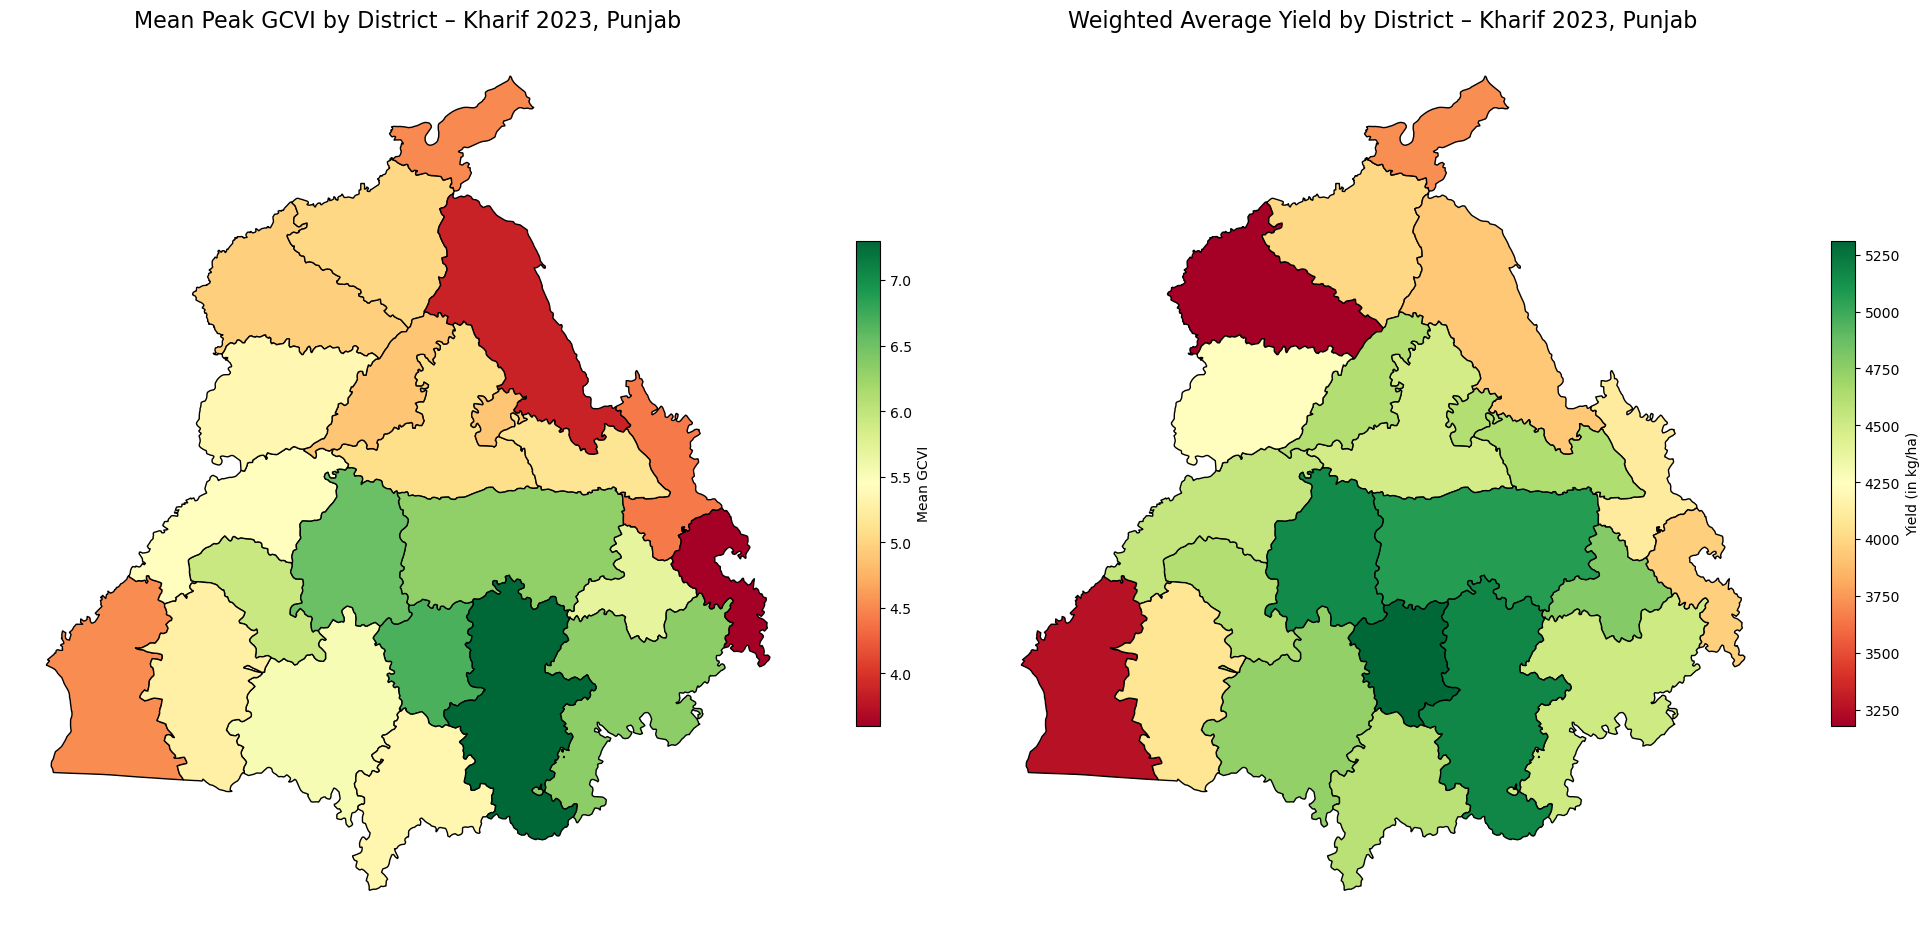

In [ ]:
# Generate a map showing mean GCVI by district and a map of yield by district
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
districts.plot(column='gcvi_mean', ax=ax[0], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Mean GCVI'})
ax[0].set_title('Mean Peak GCVI by District – Kharif 2023, Punjab', fontsize=16)
ax[0].axis('off')
districts.plot(column='weighted_yield', ax=ax[1], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Yield (in kg/ha)'})
ax[1].set_title('Weighted Average Yield by District – Kharif 2023, Punjab', fontsize=16)
ax[1].axis('off')
plt.tight_layout()
plt.show()

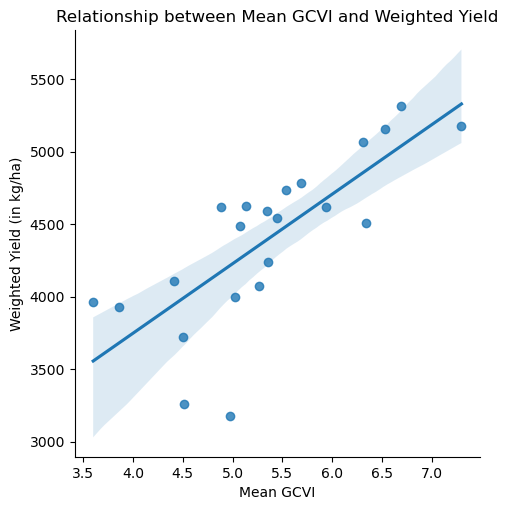

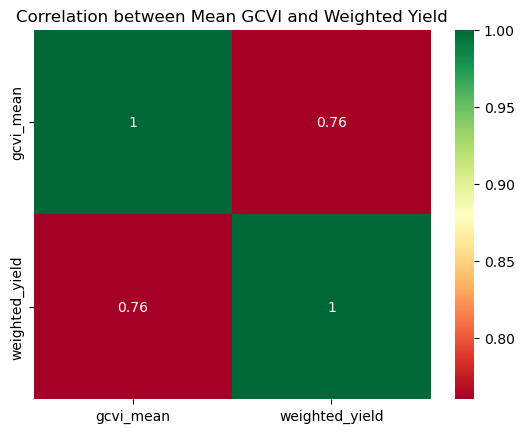

In [ ]:
# Plot the relationship between Mean GCVI and Weighted Yield with the best fit line
sns.lmplot(x='gcvi_mean', y='weighted_yield', data=districts)
plt.title('Relationship between Mean GCVI and Weighted Yield')
plt.xlabel('Mean GCVI')
plt.ylabel('Weighted Yield (in kg/ha)')
plt.show()

# Compute the correlation between Mean GCVI and Weighted Yield
correlation = districts[['gcvi_mean', 'weighted_yield']].corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn')
plt.title('Correlation between Mean GCVI and Weighted Yield')
plt.show()

### Individual crop analysis
Filters
- State: Madhya Pradesh
- Season: Kharif
- Crops: Rice, Maize

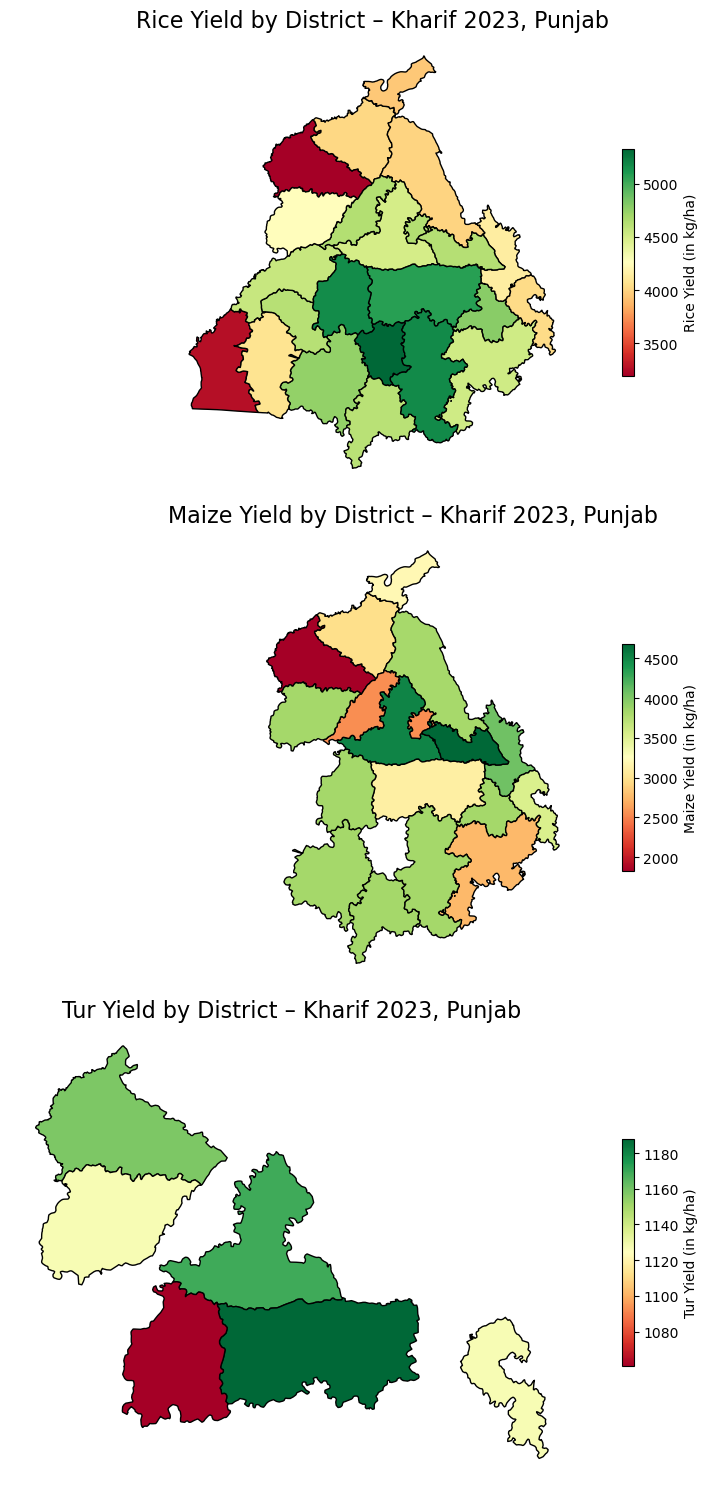

In [ ]:
# Generate a map showing mean GCVI by district and a map of yield by district and the rice and maize yield by district
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

districts.plot(column='rice_yield_kg_ha', ax=ax[0], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Rice Yield (in kg/ha)'})
ax[0].set_title('Rice Yield by District – Kharif 2023, Punjab', fontsize=16)

districts.plot(column='maize_yield_kg_ha', ax=ax[1], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Maize Yield (in kg/ha)'})
ax[1].set_title('Maize Yield by District – Kharif 2023, Punjab', fontsize=16)

districts.plot(column='tur_yield_kg_ha', ax=ax[2], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Tur Yield (in kg/ha)'})
ax[2].set_title('Tur Yield by District – Kharif 2023, Punjab', fontsize=16)

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
plt.tight_layout()
plt.show()

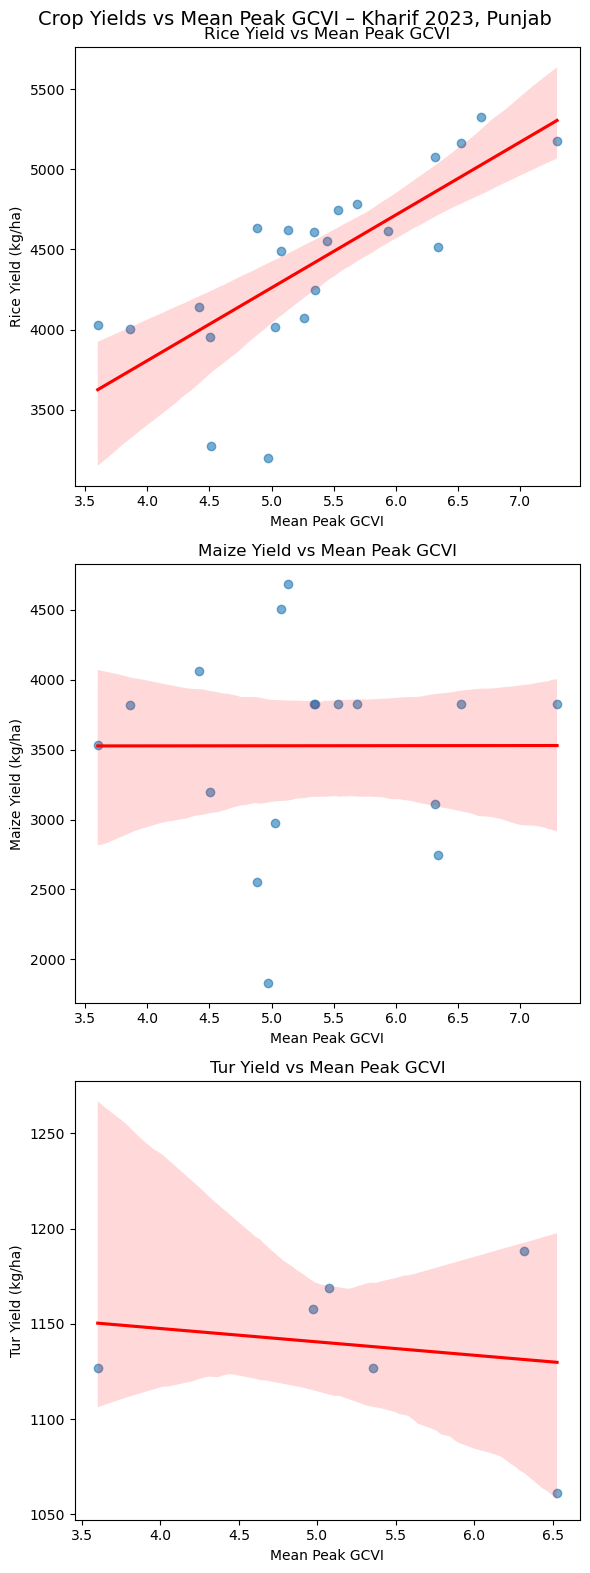

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(3, 1, figsize=(6, 16))

sns.regplot(data=districts, x='gcvi_mean', y='rice_yield_kg_ha', ax=ax[0],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[0].set_title('Rice Yield vs Mean Peak GCVI')
ax[0].set_xlabel('Mean Peak GCVI')
ax[0].set_ylabel('Rice Yield (kg/ha)')

sns.regplot(data=districts, x='gcvi_mean', y='maize_yield_kg_ha', ax=ax[1],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[1].set_title('Maize Yield vs Mean Peak GCVI')
ax[1].set_xlabel('Mean Peak GCVI')
ax[1].set_ylabel('Maize Yield (kg/ha)')

sns.regplot(data=districts, x='gcvi_mean', y='tur_yield_kg_ha', ax=ax[2],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[2].set_title('Tur Yield vs Mean Peak GCVI')
ax[2].set_xlabel('Mean Peak GCVI')
ax[2].set_ylabel('Tur Yield (kg/ha)')

plt.suptitle('Crop Yields vs Mean Peak GCVI – Kharif 2023, Punjab', fontsize=14)
plt.tight_layout()
plt.show()

Rice  — r: 0.744,  p: 0.000
Maize — r: 0.001, p: 0.997
Tur   — r: -0.166,   p: 0.754


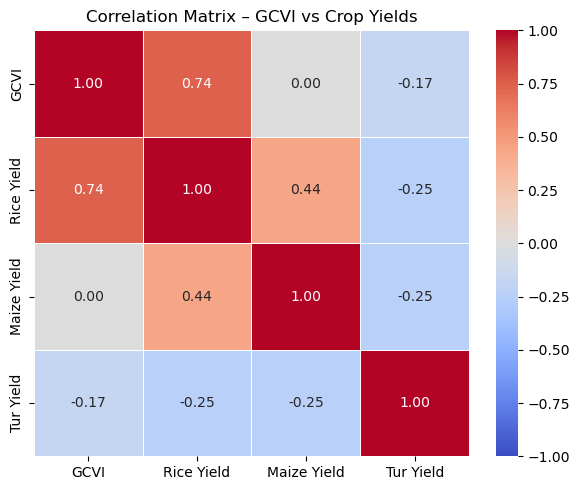

In [ ]:
import scipy.stats as stats

# Compute correlations (drop NaN rows for each crop)
rice_data  = districts[['gcvi_mean', 'rice_yield_kg_ha']].dropna()
maize_data = districts[['gcvi_mean', 'maize_yield_kg_ha']].dropna()
tur_data   = districts[['gcvi_mean', 'tur_yield_kg_ha']].dropna()

rice_r,  rice_p  = stats.pearsonr(rice_data['gcvi_mean'],  rice_data['rice_yield_kg_ha'])
maize_r, maize_p = stats.pearsonr(maize_data['gcvi_mean'], maize_data['maize_yield_kg_ha'])
tur_r,   tur_p   = stats.pearsonr(tur_data['gcvi_mean'],   tur_data['tur_yield_kg_ha'])

print(f"Rice  — r: {rice_r:.3f},  p: {rice_p:.3f}")
print(f"Maize — r: {maize_r:.3f}, p: {maize_p:.3f}")
print(f"Tur   — r: {tur_r:.3f},   p: {tur_p:.3f}")

# Visualize correlation matrix
corr_df = districts[['gcvi_mean', 'rice_yield_kg_ha', 'maize_yield_kg_ha', 'tur_yield_kg_ha']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=['GCVI', 'Rice Yield', 'Maize Yield', 'Tur Yield'],
            yticklabels=['GCVI', 'Rice Yield', 'Maize Yield', 'Tur Yield'])
ax.set_title('Correlation Matrix – GCVI vs Crop Yields')
plt.tight_layout()
plt.show()

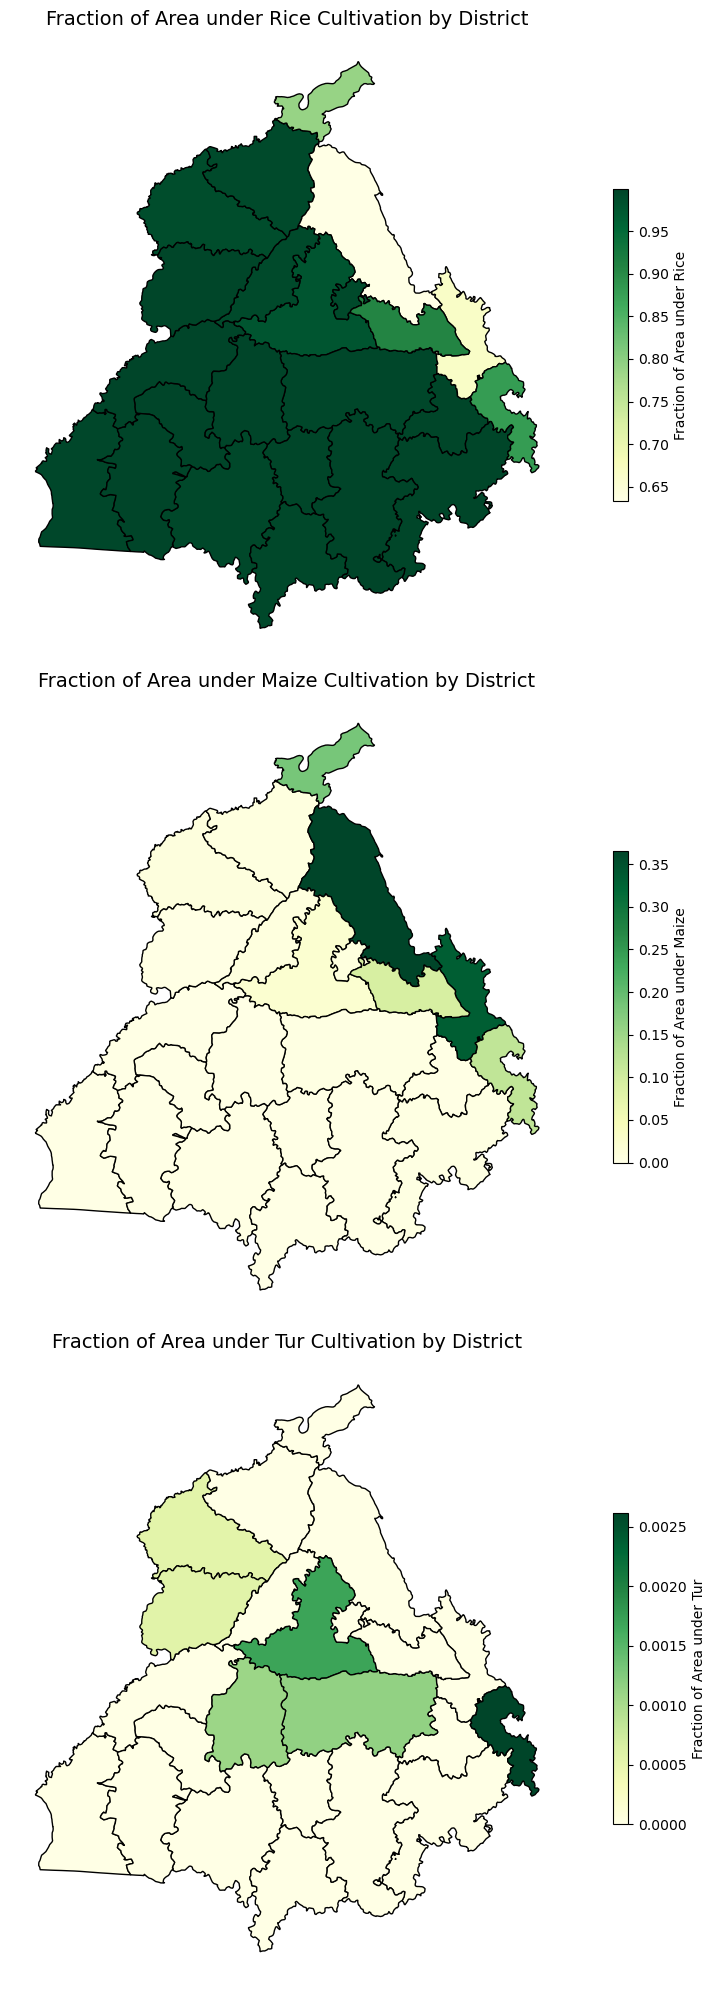

In [ ]:
# Visualize the fraction of area under rice and maize cultivation by district
fig, ax = plt.subplots(3, 1, figsize=(10,20))
districts.plot(column='rice_area_fraction', ax=ax[0], cmap='YlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Fraction of Area under Rice'})
ax[0].set_title('Fraction of Area under Rice Cultivation by District', fontsize=14)
ax[0].axis('off')
districts.plot(column='maize_area_fraction', ax=ax[1], cmap='YlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Fraction of Area under Maize'})
ax[1].set_title('Fraction of Area under Maize Cultivation by District', fontsize=14)
ax[1].axis('off')

districts.plot(column='tur_area_fraction', ax=ax[2], cmap='YlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Fraction of Area under Tur'})
ax[2].set_title('Fraction of Area under Tur Cultivation by District', fontsize=14)
ax[2].axis('off')
plt.tight_layout()
plt.show()

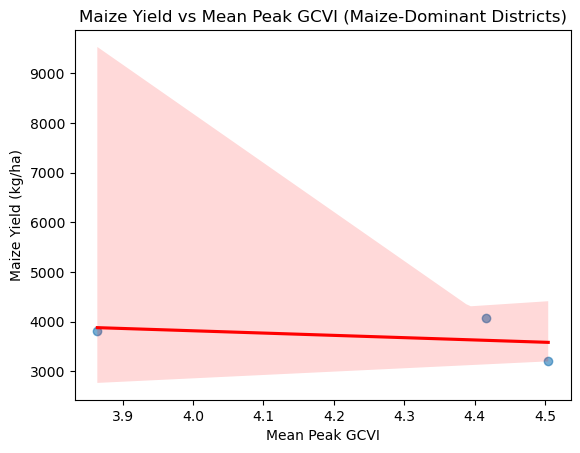

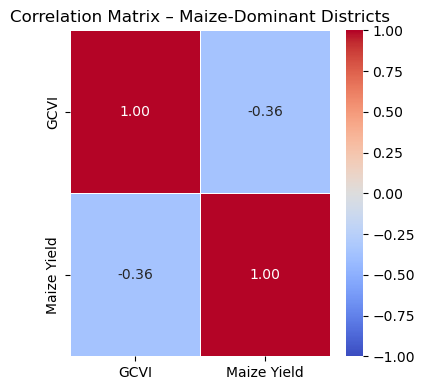

In [ ]:
# Conduct another regression analysis between maize yield and gcvi_mean but only for districts where maizee area fraction is above a threshold
maize_dominant = districts[districts['maize_area_fraction'] > 0.15]
sns.regplot(data=maize_dominant, x='gcvi_mean', y='maize_yield_kg_ha', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.title('Maize Yield vs Mean Peak GCVI (Maize-Dominant Districts)')
plt.xlabel('Mean Peak GCVI')
plt.ylabel('Maize Yield (kg/ha)')
plt.show()

# Show correlation matrix for maize-dominant districts
maize_dominant_corr = maize_dominant[['gcvi_mean', 'maize_yield_kg_ha']].corr()
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(maize_dominant_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=['GCVI', 'Maize Yield'],
            yticklabels=['GCVI', 'Maize Yield'])
ax.set_title('Correlation Matrix – Maize-Dominant Districts')
plt.tight_layout()
plt.show()